In [16]:
from pathlib import Path
import xml.etree.ElementTree as ET

cplid_root = Path("InsulatorDataSet")
defective_root = cplid_root / "Defective_Insulators"
normal_root = cplid_root / "Normal_Insulators"

#Class mapping, used everywhere downstream
class_map = {
    "insulator": 0,
    "defect": 1,
}

In [17]:
def xml_to_yolo_lines(xml_path):
    """Parse one Pascal VOC XML and return a list of YOLO-format lines."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    lines = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in class_map:
            continue  # skipping unknown classes
        class_id = class_map[class_name]
        
        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)
        
        # Convert to YOLO format
        center_x = ((xmin + xmax) / 2) / width
        center_y = ((ymin + ymax) / 2) / height
        box_w = (xmax - xmin) / width
        box_h = (ymax - ymin) / height
        
        lines.append(f"{class_id} {center_x:.6f} {center_y:.6f} {box_w:.6f} {box_h:.6f}")
    
    return lines

In [18]:
test_defect_xml = defective_root / "labels" / "defect" / "000.xml"
test_insulator_xml = defective_root / "labels" / "insulator" / "000.xml"

print("Defect XML:")
print(xml_to_yolo_lines(test_defect_xml))
print("\nInsulator XML:")
print(xml_to_yolo_lines(test_insulator_xml))

Defect XML:
['1 0.755208 0.594907 0.062500 0.055556']

Insulator XML:
['0 0.505208 0.534722 0.715278 0.208333']


In [19]:
def collect_yolo_lines_for_image(image_path, dataset_root):
    """Find all annotations for one image and return YOLO lines.
    
    Handles two structures:
      A) labels/<class_subfolder>/<stem>.xml  (defective half)
      B) labels/<stem>.xml                     (normal half)
    """
    image_stem = image_path.stem
    labels_dir = dataset_root / "labels"
    
    all_lines = []
    
    # Structure A: nested by class subfolder
    direct_xml = labels_dir / f"{image_stem}.xml"
    if direct_xml.exists():
        all_lines.extend(xml_to_yolo_lines(direct_xml))
    else:
        for label_subfolder in labels_dir.iterdir():
            if label_subfolder.is_dir():
                xml_path = label_subfolder / f"{image_stem}.xml"
                if xml_path.exists():
                    all_lines.extend(xml_to_yolo_lines(xml_path))
    
    return all_lines

In [20]:
test_normal_image = normal_root / "images" / "0049.jpg"
result = collect_yolo_lines_for_image(test_normal_image, normal_root)
print(f"Found {len(result)} objects for normal image:")
for line in result:
    print(" ", line)

Found 1 objects for normal image:
  0 0.489583 0.451389 0.833333 0.300926


In [21]:
print("Defective labels folders:", list((defective_root / "labels").iterdir()))
print("Normal labels folders:   ", list((normal_root / "labels").iterdir()))

Defective labels folders: [WindowsPath('InsulatorDataSet/Defective_Insulators/labels/defect'), WindowsPath('InsulatorDataSet/Defective_Insulators/labels/insulator')]
Normal labels folders:    [WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0049.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0051.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0056.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0058.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0059.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0060.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0062.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0069.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0071.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0078.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0082.xml'), WindowsPath('InsulatorDataSet/Normal_Insulators/labels/0085.xml'), Win

In [22]:
import shutil
import random

# Where the prepared dataset will live
output_root = Path("cplid_yolo")

# Create folders (parents=True makes intermediate folders, exist_ok=True won't error if it's there)
for split in ["train", "val"]:
    (output_root / "images" / split).mkdir(parents=True, exist_ok=True)
    (output_root / "labels" / split).mkdir(parents=True, exist_ok=True)

# Collect every image and its YOLO lines, from both halves
records = []  # list of (image_path, list_of_yolo_lines)

for dataset_root in [defective_root, normal_root]:
    image_folder = dataset_root / "images"
    for image_path in sorted(image_folder.iterdir()):
        if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        lines = collect_yolo_lines_for_image(image_path, dataset_root)
        if lines:  # only keep images that actually have annotations
            records.append((image_path, lines))

print(f"Total images with annotations: {len(records)}")

# Shuffle deterministically so the split is reproducible
random.seed(42)
random.shuffle(records)

# 80/20 split
split_idx = int(0.8 * len(records))
train_records = records[:split_idx]
val_records = records[split_idx:]

print(f"Train: {len(train_records)} images")
print(f"Val:   {len(val_records)} images")

Total images with annotations: 848
Train: 678 images
Val:   170 images


In [23]:
all_filenames = [r[0].name for r in records]
duplicates = [n for n in set(all_filenames) if all_filenames.count(n) > 1]
print("Duplicate filenames across halves:", duplicates)

Duplicate filenames across halves: []


In [24]:
def write_split(records, split_name):
    """Copy images and write YOLO labels for one split."""
    img_dir = output_root / "images" / split_name
    lbl_dir = output_root / "labels" / split_name
    
    for image_path, lines in records:
        # Copy image
        dest_image = img_dir / image_path.name
        shutil.copy(image_path, dest_image)
        
        # Write label TXT (same stem, .txt extension)
        dest_label = lbl_dir / f"{image_path.stem}.txt"
        dest_label.write_text("\n".join(lines))
    
    print(f"  {split_name}: wrote {len(records)} images + labels")

print("Writing train split...")
write_split(train_records, "train")

print("Writing val split...")
write_split(val_records, "val")

print("\nDone.")

Writing train split...
  train: wrote 678 images + labels
Writing val split...
  val: wrote 170 images + labels

Done.


In [25]:
for split in ["train", "val"]:
    img_count = len(list((output_root / "images" / split).iterdir()))
    lbl_count = len(list((output_root / "labels" / split).iterdir()))
    print(f"{split}: {img_count} images, {lbl_count} labels")

# Peek at one written label to confirm format
sample_label = next((output_root / "labels" / "train").iterdir())
print(f"\nSample label ({sample_label.name}):")
print(sample_label.read_text())

train: 678 images, 678 labels
val: 170 images, 170 labels

Sample label (000.txt):
1 0.755208 0.594907 0.062500 0.055556
0 0.505208 0.534722 0.715278 0.208333


In [26]:
yaml_content = """\
path: ../cplid_yolo
train: images/train
val: images/val

names:
  0: insulator
  1: defect
"""

yaml_path = output_root / "dataset.yaml"
yaml_path.write_text(yaml_content)

print(f"Wrote {yaml_path}")
print("---")
print(yaml_path.read_text())

Wrote cplid_yolo\dataset.yaml
---
path: ../cplid_yolo
train: images/train
val: images/val

names:
  0: insulator
  1: defect



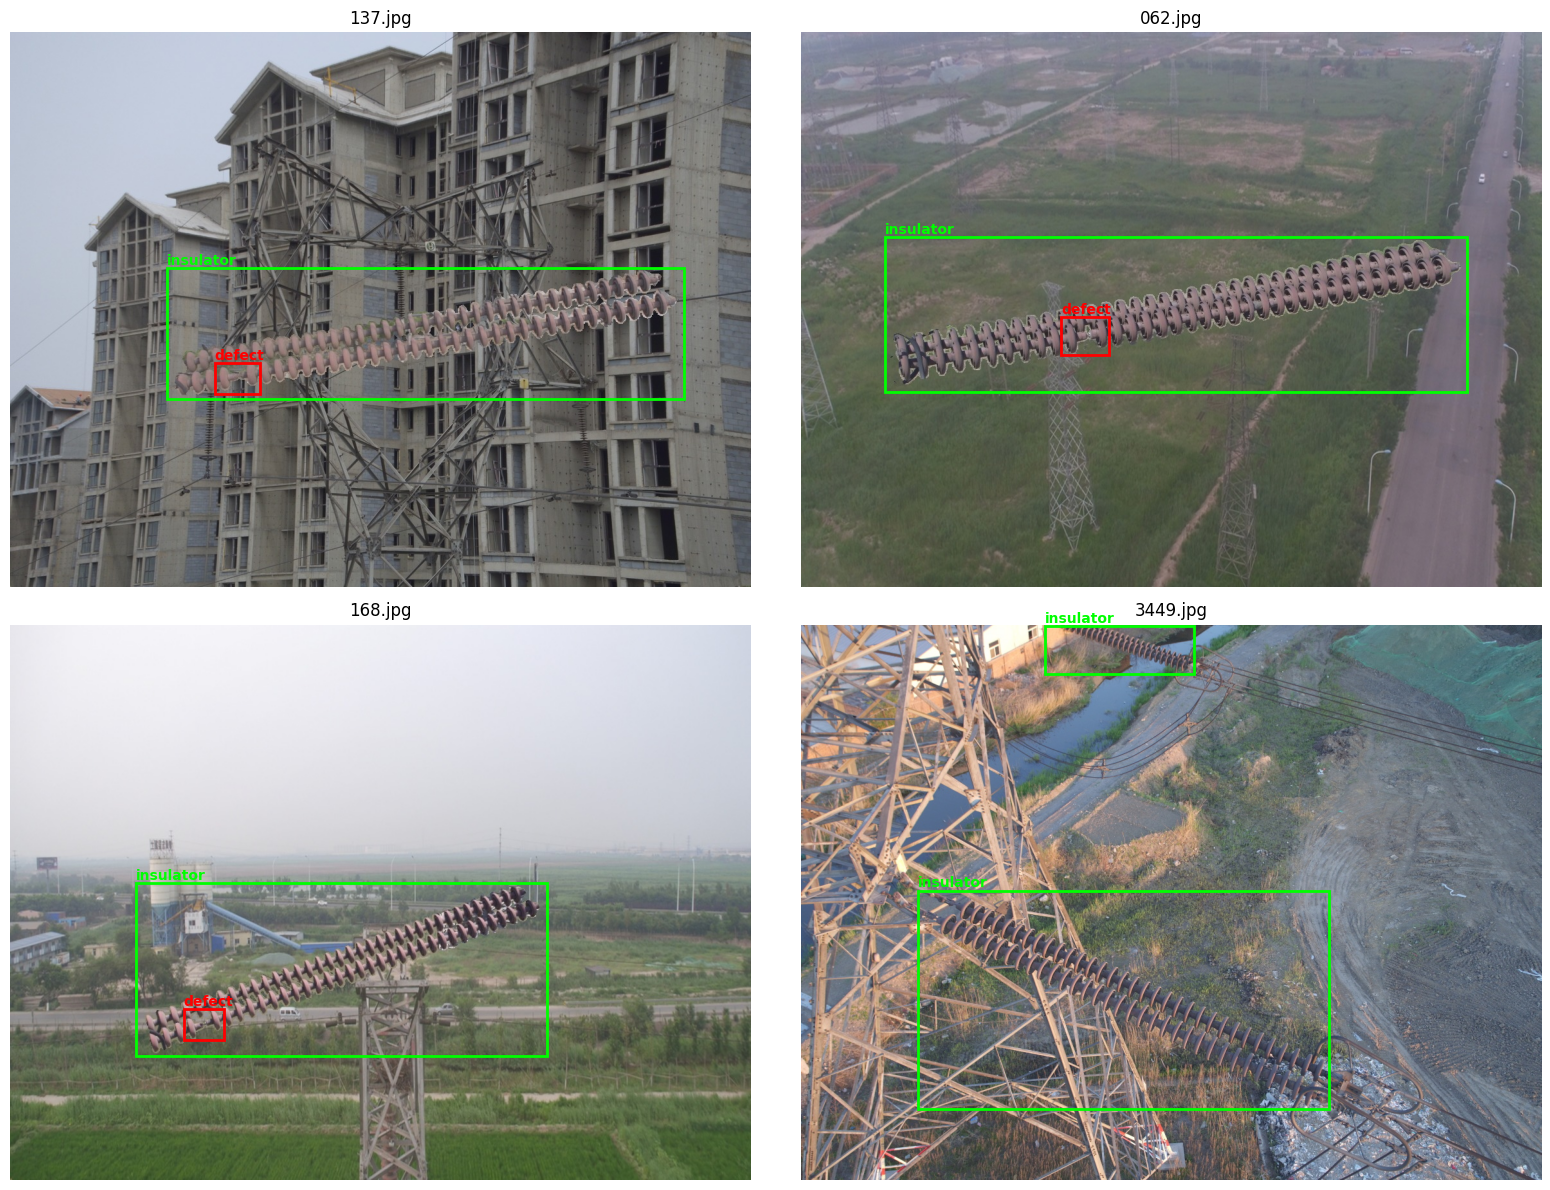

In [29]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image
def yolo_to_pixel(line, img_w, img_h):
    """Convert one YOLO line back to (class_id, xmin, ymin, xmax, ymax) in pixels."""
    parts = line.strip().split()
    class_id = int(parts[0])
    cx, cy, w, h = map(float, parts[1:])
    xmin = (cx - w/2) * img_w
    ymin = (cy - h/2) * img_h
    xmax = (cx + w/2) * img_w
    ymax = (cy + h/2) * img_h
    return class_id, xmin, ymin, xmax, ymax

class_colours = {0: "lime", 1: "red"}
class_names_inv = {0: "insulator", 1: "defect"}

# Pick 4 random images from train
random.seed(7)
sample_paths = random.sample(list((output_root / "images" / "train").iterdir()), 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, img_path in zip(axes.flat, sample_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    
    # Load the matching label
    label_path = output_root / "labels" / "train" / f"{img_path.stem}.txt"
    lines = label_path.read_text().strip().split("\n")
    
    for line in lines:
        cls, xmin, ymin, xmax, ymax = yolo_to_pixel(line, img.width, img.height)
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=class_colours[cls], facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, class_names_inv[cls],
                color=class_colours[cls], fontsize=10, weight="bold")
    
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
import shutil

archive_path = shutil.make_archive("cplid_yolo", "zip", root_dir=".", base_dir="cplid_yolo")
print(f"Created: {archive_path}")
print(f"Size: {Path(archive_path).stat().st_size / 1e6:.1f} MB")

Created: C:\Users\Vansheeka\Desktop\power-line-digital-twin\cplid_yolo.zip
Size: 408.5 MB
